# WBCAtt+ — kiểm tra và khám phá dữ liệu

Notebook này kiểm tra split chính thức, ảnh–mask, sáu nhãn pixel, phân bố loại bạch cầu, mất cân bằng pixel và augmentation trước khi huấn luyện U-Net.

In [11]:
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

## 1. Cấu hình đường dẫn

Giữ cấu hình `local` khi chạy trên máy. Khi đưa lên Kaggle, đổi ba đường dẫn sang `/kaggle/input/...`.

In [12]:
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "pbcseg_final_v1" / "pbcseg_final_v1"
CSV_DIR = PROJECT_DIR / "dataset_txt"

IMAGE_SIZE = (360, 360)
SEED = 42

assert DATA_DIR.is_dir(), f"Không tìm thấy DATA_DIR: {DATA_DIR}"
assert CSV_DIR.is_dir(), f"Không tìm thấy CSV_DIR: {CSV_DIR}"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from wbcatt_dataset import (
    CLASS_COLORS,
    CLASS_NAMES,
    SPLIT_FILES,
    colorize_mask,
    create_dataloaders,
    create_datasets,
    mask_name_from_image,
    pixel_class_counts,
    seed_everything,
    validate_official_splits,
)

seed_everything(SEED)
print("DATA_DIR:", DATA_DIR)
print("CSV_DIR :", CSV_DIR)

DATA_DIR: C:\Computer Vision\pbcseg_final_v1\pbcseg_final_v1
CSV_DIR : C:\Computer Vision\dataset_txt


## 2. Kiểm tra split chính thức

Kết quả hợp lệ phải có: không trùng giữa ba tập, không thiếu ảnh/mask và tổng cộng 10.298 ảnh.

In [13]:
split_report = validate_official_splits(DATA_DIR, CSV_DIR)
pprint(split_report)
assert split_report["is_valid"], "Split hoặc cặp ảnh–mask chưa hợp lệ."

{'csv_images_not_on_disk': [],
 'csv_unique_images': 10298,
 'declared_splits': {'test': ['test'], 'train': ['train'], 'val': ['val']},
 'disk_images_not_in_csv': [],
 'disk_unique_images': 10298,
 'duplicate_counts': {'test': 0, 'train': 0, 'val': 0},
 'is_valid': True,
 'missing_masks': [],
 'overlaps': {'train_test': 0, 'train_val': 0, 'val_test': 0},
 'split_rows': {'test': 3099, 'train': 6169, 'val': 1030}}


In [14]:
frames = {
    split: pd.read_csv(CSV_DIR / filename)
    for split, filename in SPLIT_FILES.items()
}

summary = pd.DataFrame(
    {split: frame["label"].value_counts() for split, frame in frames.items()}
).fillna(0).astype(int)
summary.loc["TOTAL"] = summary.sum(axis=0)
display(summary)

,train,val,test
label,,,
Basophil,744,125,349
Eosinophil,1876,314,927
Lymphocyte,736,111,367
Monocyte,829,146,445
Neutrophil,1984,334,1011
TOTAL,6169,1030,3099


## 3. Tạo Dataset và kiểm tra tensor

Trong bước khám phá, tắt augmentation để ảnh hiển thị đúng với mask gốc.

In [15]:
datasets_no_aug = create_datasets(
    data_dir=DATA_DIR,
    csv_dir=CSV_DIR,
    image_size=IMAGE_SIZE,
    train_augment=False,
)

print({split: len(dataset) for split, dataset in datasets_no_aug.items()})
SAMPLE_IMAGE_NAME = "BA_773081_ccrop.jpg"
sample_index = datasets_no_aug["train"].image_names.index(SAMPLE_IMAGE_NAME)
sample = datasets_no_aug["train"][sample_index]
print("image shape :", tuple(sample["image"].shape))
print("image dtype :", sample["image"].dtype)
print("image range :", float(sample["image"].min()), float(sample["image"].max()))
print("mask shape  :", tuple(sample["mask"].shape))
print("mask dtype  :", sample["mask"].dtype)
print("mask values :", torch.unique(sample["mask"]).tolist())
print("image name  :", sample["image_name"])
print("cell type   :", sample["cell_type"])

{'train': 6169, 'val': 1030, 'test': 3099}
image shape : (3, 360, 360)
image dtype : torch.float32
image range : 0.0 1.0
mask shape  : (360, 360)
mask dtype  : torch.int64
mask values : [0, 1, 2, 3, 4, 5]
image name  : BA_773081_ccrop.jpg
cell type   : Basophil


## 4. Trực quan hóa ảnh, mask và overlay

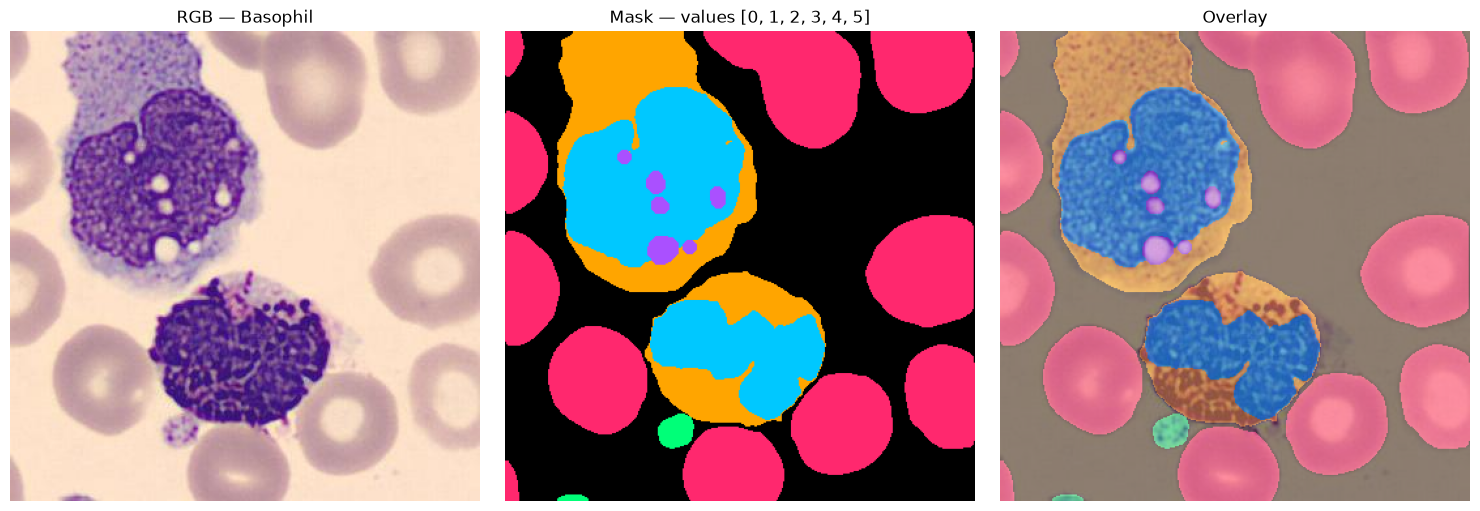

In [16]:
def show_sample(sample):
    image = sample["image"].permute(1, 2, 0).numpy()
    mask = sample["mask"].numpy()
    mask_rgb = colorize_mask(mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title(f"RGB — {sample['cell_type']}")
    axes[1].imshow(mask_rgb)
    axes[1].set_title(f"Mask — values {np.unique(mask).tolist()}")
    axes[2].imshow(image)
    axes[2].imshow(mask_rgb, alpha=0.45)
    axes[2].set_title("Overlay")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()

show_sample(sample)

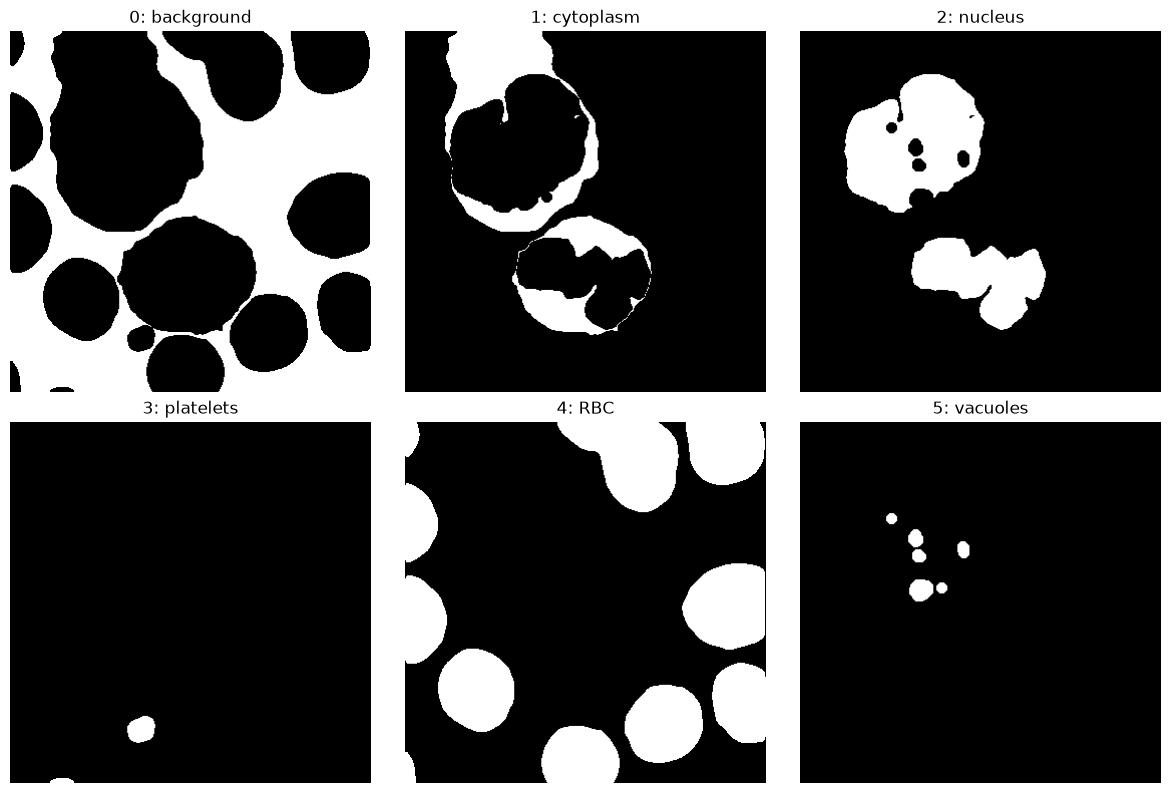

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
mask = sample["mask"].numpy()
for class_id, (axis, class_name) in enumerate(zip(axes.flat, CLASS_NAMES)):
    axis.imshow(mask == class_id, cmap="gray")
    axis.set_title(f"{class_id}: {class_name}")
    axis.axis("off")
plt.tight_layout()

## 5. Thống kê mất cân bằng pixel

Đặt `MAX_STATS_IMAGES = 1000` để chạy nhanh, hoặc `None` để quét toàn bộ 6.169 mask train.

,class_id,class_name,pixels,ratio_percent
0,0,background,67364660,51.978904
1,1,cytoplasm,6633288,5.118278
2,2,nucleus,6655866,5.135699
3,3,platelets,417813,0.322387
4,4,RBC,48511495,37.431709
5,5,vacuoles,16878,0.013023


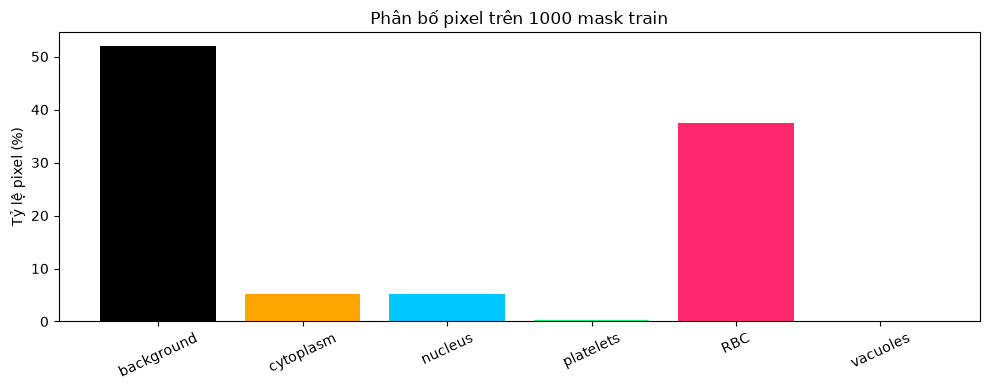

In [18]:
MAX_STATS_IMAGES = 1000
train_mask_paths = [
    DATA_DIR / mask_name_from_image(Path(path).name)
    for path in frames["train"]["path"]
]
pixel_counts = pixel_class_counts(train_mask_paths, max_images=MAX_STATS_IMAGES)
pixel_ratios = pixel_counts / pixel_counts.sum()
pixel_table = pd.DataFrame({
    "class_id": range(len(CLASS_NAMES)),
    "class_name": CLASS_NAMES,
    "pixels": pixel_counts,
    "ratio_percent": pixel_ratios * 100,
})
display(pixel_table)

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, pixel_ratios * 100, color=CLASS_COLORS / 255.0)
plt.ylabel("Tỷ lệ pixel (%)")
plt.title(f"Phân bố pixel trên {MAX_STATS_IMAGES or len(train_mask_paths)} mask train")
plt.xticks(rotation=25)
plt.tight_layout()

## 6. Kiểm tra augmentation

Ảnh và mask phải luôn được lật/xoay cùng nhau. Augmentation chỉ bật cho tập train.

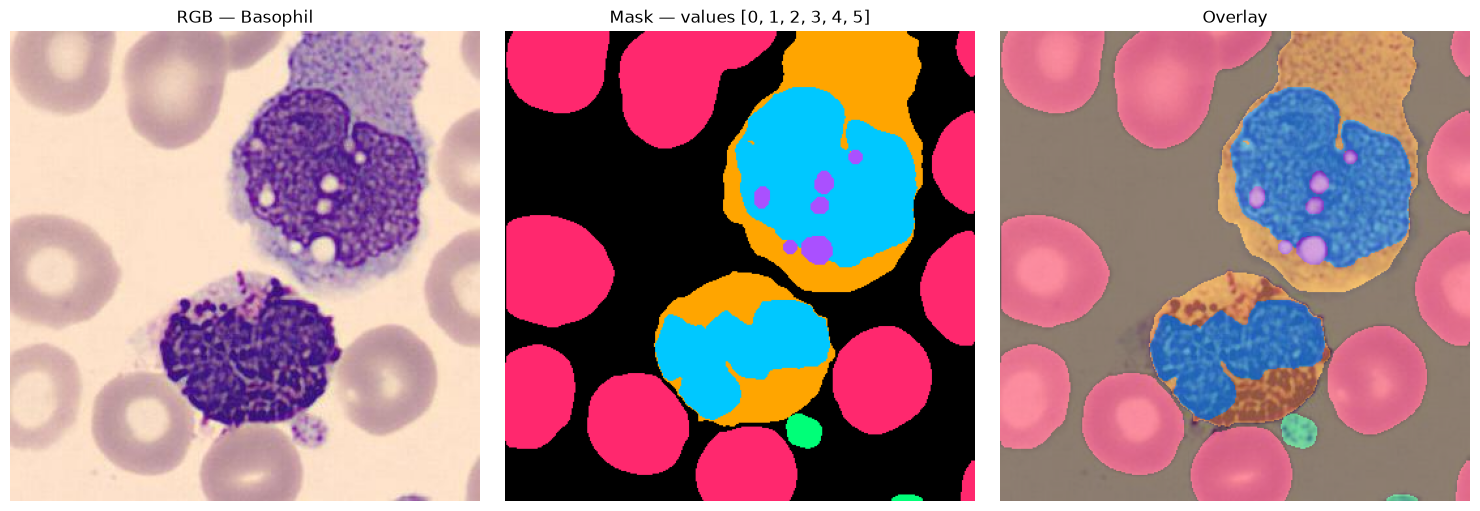

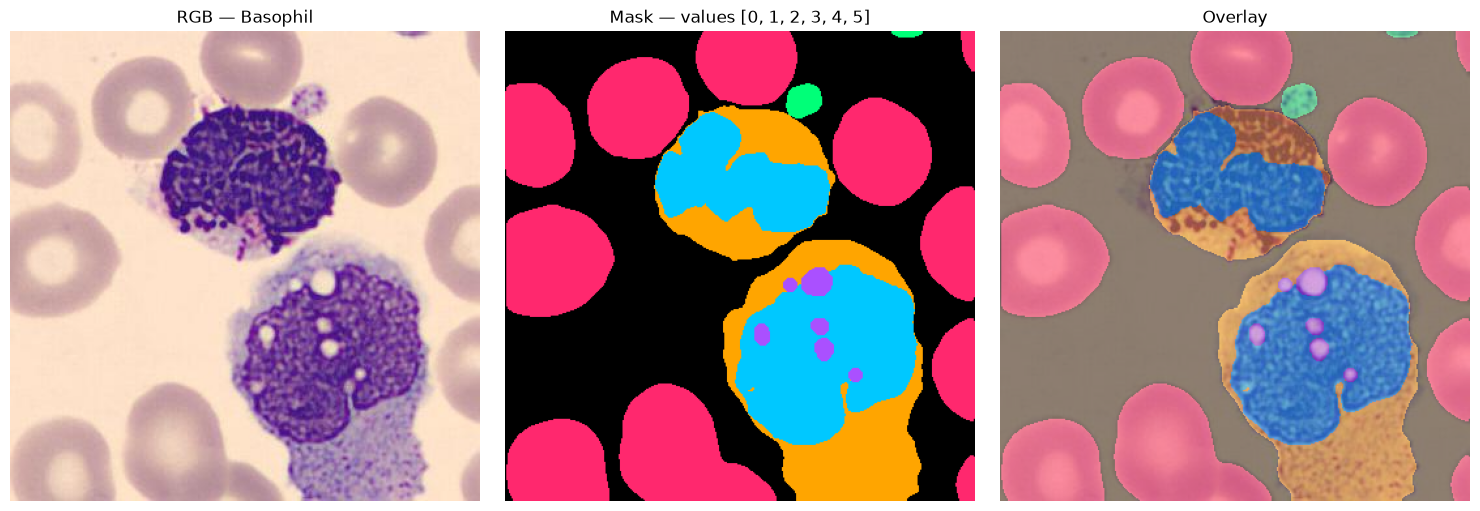

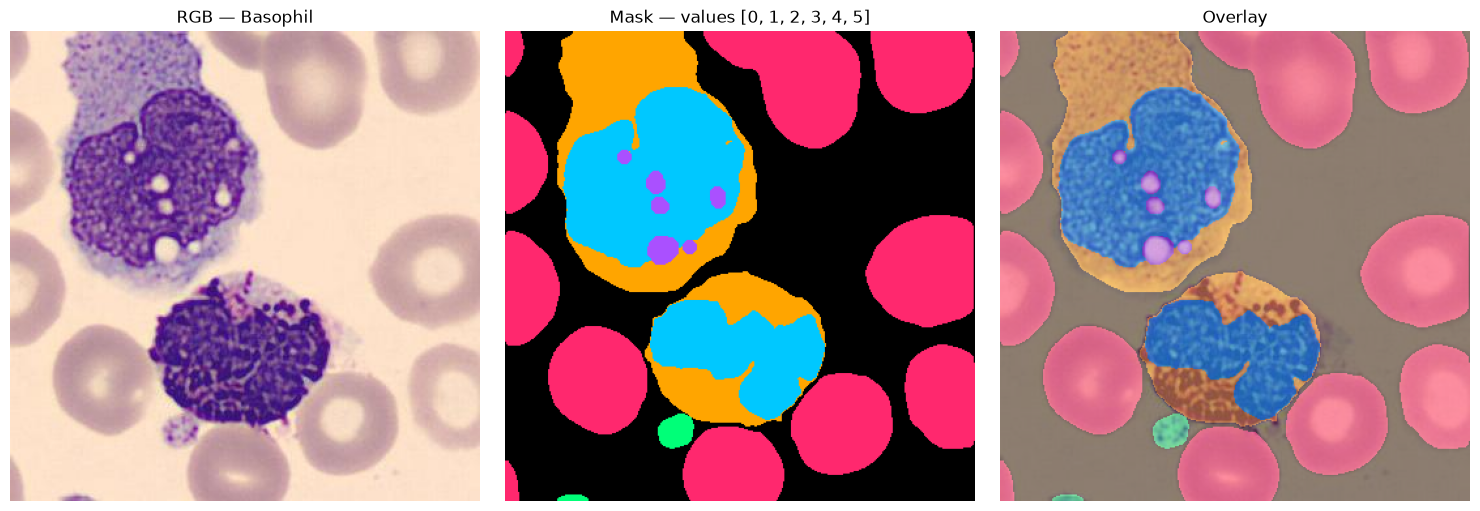

In [19]:
datasets_aug = create_datasets(
    data_dir=DATA_DIR,
    csv_dir=CSV_DIR,
    image_size=IMAGE_SIZE,
    train_augment=True,
)

aug_sample_index = datasets_aug["train"].image_names.index(SAMPLE_IMAGE_NAME)
for _ in range(3):
    show_sample(datasets_aug["train"][aug_sample_index])

## 7. DataLoader smoke test

Trên Windows/Jupyter nên bắt đầu với `num_workers=0`. Trên Kaggle có thể tăng lên 2–4.

In [20]:
loaders = create_dataloaders(
    datasets_aug,
    batch_size=4,
    num_workers=0,
    seed=SEED,
)
batch = next(iter(loaders["train"]))
print("batch images:", tuple(batch["image"].shape))
print("batch masks :", tuple(batch["mask"].shape))
print("mask values :", torch.unique(batch["mask"]).tolist())
assert batch["image"].shape[1:] == (3, *IMAGE_SIZE)
assert batch["mask"].shape[1:] == IMAGE_SIZE
assert set(torch.unique(batch["mask"]).tolist()).issubset(set(range(6)))

batch images: (4, 3, 360, 360)
batch masks : (4, 360, 360)
mask values : [0, 1, 2, 3, 4]
